<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Leverage_ETFs/LMR_Discrete_Daily_Allocator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TQQQ Current Market Analysis with Logarithmic Trend Mean Reversion

This notebook provides a real-time analysis of TQQQ (ProShares UltraPro QQQ 3x Leveraged ETF) relative to its long-term logarithmic trend. The core purpose is to identify the current market regime based on historically established residual levels and recommend a strategic allocation.

## Key Components:

1.  **Data Acquisition and Preparation:** TQQQ price data is downloaded from `yfinance` up to the current date. Logarithmic prices, a linear trend, and residuals (deviations from the trend) are calculated.

2.  **Historical Residual Regime Definition:** A critical step involves recreating a `regression_df` using TQQQ data *only* from 2010-02-11 to 2026-01-01. The residuals from this historical period are then used to train a Gaussian Mixture Model (GMM).
    *   This ensures that the defined market regimes (e.g., 'oversold', 'overbought') are static and based on the backtesting period's characteristics, not dynamically shifting with new data.
    *   The `residual_component_count` is currently set to 2.

3.  **Current Market State Classification:** The latest TQQQ residual (calculated from up-to-date data) is classified into one of the historically derived GMM regimes. This classification determines the current market sentiment (e.g., how oversold or overbought TQQQ is relative to its historical trend).

4.  **Strategic Allocation Recommendation:** Based on the identified current market regime, a target allocation (e.g., 100% long, 0% long) is recommended.

5.  **Visualization:** Plots illustrate TQQQ's logarithmic price, its linear trend, and the residuals over the last two years, visually highlighting the current market position.

In [114]:
# Import necessary libraries

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Ensure display is available
from ipywidgets import interact, FloatSlider



In [115]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: tqqq_data_backtest
Deleted DataFrame: regression_df
Deleted DataFrame: X_backtest
Deleted DataFrame: current_analysis_tqqq_data
Deleted DataFrame: current_analysis_df
Deleted DataFrame: X_current_analysis
Deleted DataFrame: temp_df_for_summary_historical
Deleted DataFrame: residual_summary_current_gmm
Deleted DataFrame: plot_df
All DataFrames cleared from memory.


## Current Market Analysis: TQQQ Price and Strategy Allocation

This section allows you to analyze the current position of TQQQ relative to its logarithmic trend for a specified number of GMM components. We'll determine the current residual regime and the strategy's recommended allocation.

In [116]:
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.linear_model import LinearRegression

# Download TQQQ data for the backtesting period
tickers = ["TQQQ"]
tqqq_data_backtest = yf.download(tickers, start="2010-02-11", end="2026-01-01", auto_adjust=True)['Close'].dropna()

# Convert to DataFrame if it's a Series
if isinstance(tqqq_data_backtest, pd.Series):
    tqqq_data_backtest = tqqq_data_backtest.to_frame(name='TQQQ')

# Create a copy for regression analysis, representing the original backtest data
regression_df = tqqq_data_backtest.copy()

# Calculate TQQQ log price
regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])

# Calculate 'Days_Since_Start'
# Using a consistent start for 'Days_Since_Start' as in the original setup
regression_df['Days_Since_Start'] = (regression_df.index - regression_df.index[0]).days

# Fit Linear Regression model on this historical data
X_backtest = regression_df[['Days_Since_Start']]
y_backtest = regression_df['TQQQ_Log_Price']
model_backtest = LinearRegression()
model_backtest.fit(X_backtest, y_backtest)
regression_df['TQQQ_Trend_Line'] = model_backtest.predict(X_backtest)

# Calculate residuals for the backtesting period
regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

print("Historical `regression_df` (up to 2026-01-01) recreated successfully.")
# Displaying head to confirm
display(regression_df.head())

[*********************100%***********************]  1 of 1 completed

Historical `regression_df` (up to 2026-01-01) recreated successfully.


Ticker,TQQQ,TQQQ_Log_Price,Days_Since_Start,TQQQ_Trend_Line,TQQQ_Residuals
Date,,,,,
2010-02-11,0.206055,-1.579611,0,-1.289064,-0.290547
2010-02-12,0.206898,-1.575527,1,-1.288128,-0.287399
2010-02-16,0.214913,-1.537522,5,-1.284386,-0.253136
2010-02-17,0.218560,-1.520695,6,-1.283451,-0.237244
2010-02-18,0.222704,-1.501914,7,-1.282515,-0.219399


In [117]:
residual_component_count = 2

print(f"Analyzing current market conditions using a {residual_component_count}-component GMM strategy.")

Analyzing current market conditions using a 2-component GMM strategy.


In [118]:
from datetime import datetime, timedelta

# --- Step 1: Re-pull ALL TQQQ data from 2010-02-11 to present for current analysis ---
# This creates a separate, up-to-date dataset for current market analysis without altering regression_df
tickers = ["TQQQ"]
start_date_str_full = "2010-02-11"
current_analysis_tqqq_data = yf.download(tickers, start=start_date_str_full, end=datetime.today() + timedelta(days=1), auto_adjust=True)['Close'].dropna()

if isinstance(current_analysis_tqqq_data, pd.Series):
    current_analysis_tqqq_data = current_analysis_tqqq_data.to_frame(name='TQQQ')

current_analysis_df = current_analysis_tqqq_data.copy()

# Calculate TQQQ log price for the current analysis data
current_analysis_df['TQQQ_Log_Price'] = np.log(current_analysis_df['TQQQ'])

# Calculate 'Days_Since_Start' for the current analysis data
# Define start_date_for_trend directly within this section for independence
start_date_for_trend_full = pd.to_datetime(start_date_str_full)
current_analysis_df['Days_Since_Start'] = (current_analysis_df.index - start_date_for_trend_full).days

# Fit a NEW LinearRegression model using the current_analysis_df itself
X_current_analysis = current_analysis_df[['Days_Since_Start']]
y_current_analysis = current_analysis_df['TQQQ_Log_Price']
current_trend_model = LinearRegression() # Create a new model instance
current_trend_model.fit(X_current_analysis, y_current_analysis)
current_analysis_df['TQQQ_Trend_Line'] = current_trend_model.predict(X_current_analysis)

# Calculate residuals for the current analysis data
current_analysis_df['TQQQ_Residuals'] = current_analysis_df['TQQQ_Log_Price'] - current_analysis_df['TQQQ_Trend_Line']


# --- Step 2: Extract current market conditions from the *latest* data point in current_analysis_df ---
current_date = current_analysis_df.index[-1]
current_price = current_analysis_df['TQQQ'].iloc[-1]
current_log_price = current_analysis_df['TQQQ_Log_Price'].iloc[-1]
current_trend_line = current_analysis_df['TQQQ_Trend_Line'].iloc[-1]
current_residual = current_analysis_df['TQQQ_Residuals'].iloc[-1]

print(f"\nCurrent Date: {current_date.strftime('%Y-%m-%d')}")
print(f"Current TQQQ Price: {current_price:.2f}")
print(f"Current Log TQQQ Price: {current_log_price:.4f}")
print(f"Predicted Trend Line at Current Date: {current_trend_line:.4f}")
print(f"Current Residual: {current_residual:.4f}")

# --- Step 3: Fit GMM using HISTORICAL residuals from `regression_df` ---
# This ensures GMM regimes are based on the backtesting period's characteristics
X_residuals_historical = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)
gmm_historical_fit = GaussianMixture(n_components=residual_component_count, random_state=42, covariance_type='full')
gmm_historical_fit.fit(X_residuals_historical)

# Sort the GMM means to map raw labels to ordered regimes (0 = most oversold, n-1 = most overbought)
idx_residuals_historical = np.argsort(gmm_historical_fit.means_.flatten())
state_map_residuals_historical = {old_label: new_label for new_label, old_label in enumerate(idx_residuals_historical)}

# Predict the raw label for the *current* residual using the historically trained GMM
current_raw_label = gmm_historical_fit.predict([[current_residual]])[0]

# Get the ordered regime for the current residual
current_regime_number = state_map_residuals_historical[current_raw_label]

# Dynamically define allocation_map based on n_components (consistent with run_discrete_gmm_strategy)
# Allocations range from 1.0 (most oversold) to 0.0 (most overbought)
allocation_map_current = {i: 1.0 - (i / (residual_component_count - 1)) if residual_component_count > 1 else 1.0 for i in range(residual_component_count)}

current_target_allocation = allocation_map_current[current_regime_number]

# --- Step 4: Generate a summary of discovered residual regimes for this GMM setup using HISTORICAL residuals ---
predicted_regimes_for_summary_historical = [state_map_residuals_historical[label] for label in gmm_historical_fit.predict(X_residuals_historical)]
temp_df_for_summary_historical = pd.DataFrame({
    'TQQQ_Residuals': regression_df['TQQQ_Residuals'], # Use residuals from historical regression_df
    'Residual_Regime': predicted_regimes_for_summary_historical
})
residual_summary_current_gmm = temp_df_for_summary_historical.groupby('Residual_Regime')['TQQQ_Residuals'].agg(['min', 'max', 'mean', 'count'])
allocation_series_current = pd.Series(allocation_map_current, name='Target_Allocation')
residual_summary_current_gmm = residual_summary_current_gmm.merge(allocation_series_current.to_frame(), left_index=True, right_index=True)

print(f"\n--- DISCOVERED HISTORICAL RESIDUAL REGIMES ({residual_component_count} Components) ---")
display(residual_summary_current_gmm)
print(f"Current Residual Regime (based on historical ranges): {current_regime_number}")
print(f"Recommended Target Allocation: {current_target_allocation:.2f}")

[*********************100%***********************]  1 of 1 completed


Current Date: 2026-06-16
Current TQQQ Price: 81.22
Current Log TQQQ Price: 4.3971
Predicted Trend Line at Current Date: 4.2759
Current Residual: 0.1212

--- DISCOVERED HISTORICAL RESIDUAL REGIMES (2 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.061780,0.190190,-0.171494,2865,1.0
1,0.190711,1.012226,0.434038,1132,0.0


Current Residual Regime (based on historical ranges): 0
Recommended Target Allocation: 1.00


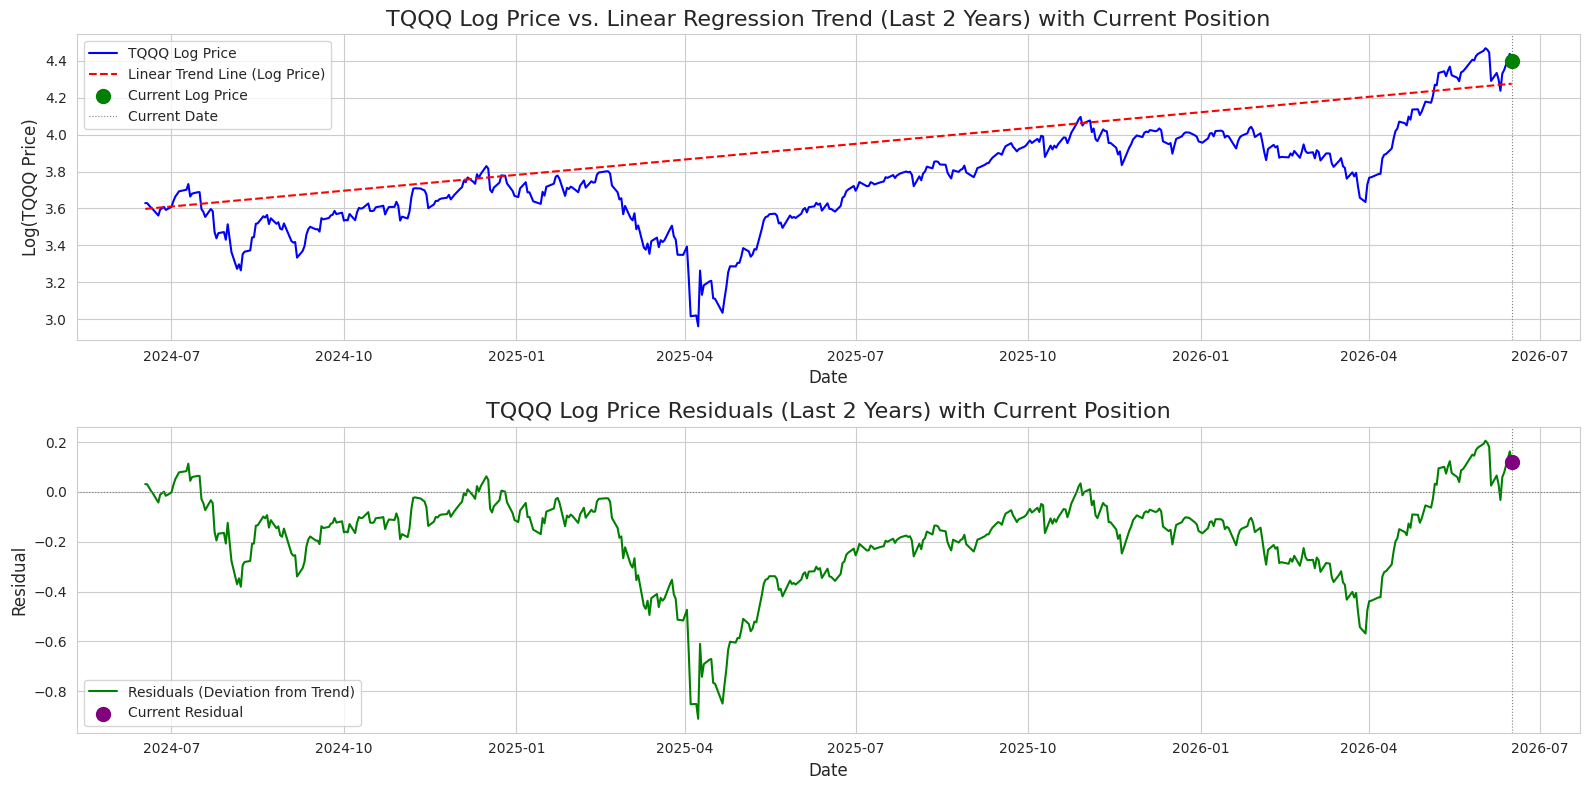

In [119]:
# Plot TQQQ log price, trend, and residuals with current position highlighted
sns.set_style('whitegrid')
plt.figure(figsize=(16, 8))

# Define the plot range for the last two years, ending at the current date
plot_end_date = current_date
plot_start_date = plot_end_date - pd.DateOffset(years=2)

# Filter the current_analysis_df for the plotting range
# This dataframe already contains log price, trend line and residuals for the full updated history
plot_df = current_analysis_df.loc[plot_start_date:plot_end_date]

# Plot Log Price and Trend Line
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(plot_df.index, plot_df['TQQQ_Log_Price'], label='TQQQ Log Price', color='blue')
plt.plot(plot_df.index, plot_df['TQQQ_Trend_Line'], label='Linear Trend Line (Log Price)', color='red', linestyle='--')

# Highlight current log price
plt.scatter(current_date, current_log_price, color='green', s=100, zorder=5, label='Current Log Price')
plt.axvline(current_date, color='gray', linestyle=':', linewidth=0.8, label='Current Date')

plt.title('TQQQ Log Price vs. Linear Regression Trend (Last 2 Years) with Current Position', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log(TQQQ Price)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

# Plot Residuals
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(plot_df.index, plot_df['TQQQ_Residuals'], label='Residuals (Deviation from Trend)', color='green')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)

# Highlight current residual
plt.scatter(current_date, current_residual, color='purple', s=100, zorder=5, label='Current Residual')
plt.axvline(current_date, color='gray', linestyle=':', linewidth=0.8)

plt.title('TQQQ Log Price Residuals (Last 2 Years) with Current Position', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.show()